# ☁️ Cloud Cost Intelligence Platform for Smart City
### AI, Cloud Computing and DevOps — Project B
**Tools Used:** Python · Pandas · Matplotlib · OpenPyXL (Excel Export)

---
## 🎯 Objective
Analyze cloud billing data from a Smart City infrastructure using Python and Pandas.
We will:
- Load and inspect a CSV billing file
- Group costs by **Service Type** and **Month**
- Generate **Pie Charts** and **Bar Charts** for visual analysis
- Export a summary report to **Excel (.xlsx)**

## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 100

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load the billing data
df = pd.read_csv('smart_city_billing.csv')

print("✅ Dataset loaded successfully!")
print(f"📊 Total Records: {len(df)}")
print(f"📋 Columns: {list(df.columns)}")
print()
df.head(10)

✅ Dataset loaded successfully!
📊 Total Records: 60
📋 Columns: ['Invoice_ID', 'Month', 'Service_Type', 'Department', 'Usage_Hours', 'Cost_USD']



,Invoice_ID,Month,Service_Type,Department,Usage_Hours,Cost_USD
0,INV-001,January,Compute,Traffic Management,720,1440.00
1,INV-002,January,Storage,Public Safety,500,75.00
2,INV-003,January,Networking,Smart Lighting,300,180.00
3,INV-004,January,Database,Waste Management,200,300.00
4,INV-005,January,AI/ML Services,Traffic Management,100,850.00
5,INV-006,February,Compute,Traffic Management,750,1500.00
6,INV-007,February,Storage,Public Safety,520,78.00
7,INV-008,February,Networking,Smart Lighting,310,186.00
8,INV-009,February,Database,Water Supply,210,315.00
9,INV-010,February,AI/ML Services,Traffic Management,120,1020.00


In [3]:
print("=" * 50)
print("📌 DATASET INFO")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("📌 BASIC STATISTICS")
print("=" * 50)
print(df.describe())

print("\n" + "=" * 50)
print("📌 MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print("\n✅ No missing values found!" if df.isnull().sum().sum() == 0 else "⚠️ Missing values detected!")

📌 DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Invoice_ID    60 non-null     str    
 1   Month         60 non-null     str    
 2   Service_Type  60 non-null     str    
 3   Department    60 non-null     str    
 4   Usage_Hours   60 non-null     int64  
 5   Cost_USD      60 non-null     float64
dtypes: float64(1), int64(1), str(4)
memory usage: 2.9 KB

📌 BASIC STATISTICS
       Usage_Hours  Cost_USD
count        60.00     60.00
mean        427.83    693.72
std         255.89    623.21
min          90.00     72.00
25%         226.25    196.50
50%         342.50    375.00
75%         622.50   1285.62
max         950.00   1900.00

📌 MISSING VALUES
Invoice_ID      0
Month           0
Service_Type    0
Department      0
Usage_Hours     0
Cost_USD        0
dtype: int64

✅ No missing values found!


In [4]:
# Group by Service Type
service_cost = df.groupby('Service_Type')['Cost_USD'].sum().sort_values(ascending=False)

print("=" * 40)
print("💰 TOTAL COST BY SERVICE TYPE")
print("=" * 40)
for service, cost in service_cost.items():
    print(f"  {service:<20} ${cost:,.2f}")
print("-" * 40)
print(f"  {'TOTAL':<20} ${service_cost.sum():,.2f}")

💰 TOTAL COST BY SERVICE TYPE
  Compute              $19,920.00
  AI/ML Services       $13,727.50
  Database             $4,455.00
  Networking           $2,469.00
  Storage              $1,051.50
----------------------------------------
  TOTAL                $41,623.00


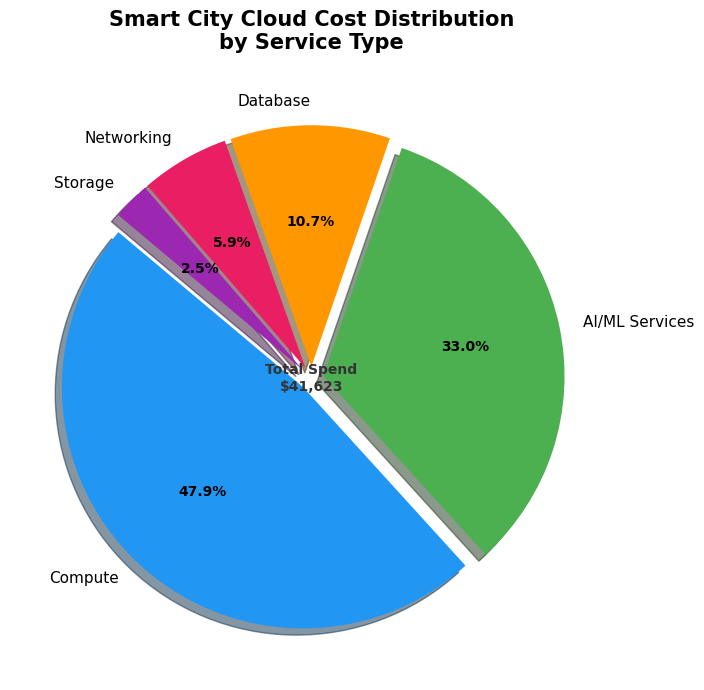

✅ Pie chart saved as 'pie_by_service.png'


In [5]:
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
explode = [0.05] * len(service_cost)

fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    service_cost.values,
    labels=service_cost.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=140,
    shadow=True,
    textprops={'fontsize': 11}
)

for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Smart City Cloud Cost Distribution\nby Service Type', 
             fontsize=15, fontweight='bold', pad=20)

# Add total cost annotation
total = service_cost.sum()
ax.annotate(f'Total Spend\n${total:,.0f}', xy=(0, 0), 
            ha='center', va='center', fontsize=10, fontweight='bold',
            color='#333333')

plt.tight_layout()
plt.savefig('pie_by_service.png', bbox_inches='tight', dpi=120)
plt.show()
print("✅ Pie chart saved as 'pie_by_service.png'")

In [6]:
# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_cost = df.groupby('Month')['Cost_USD'].sum()
monthly_cost = monthly_cost.reindex(month_order)

print("=" * 40)
print("📅 TOTAL COST BY MONTH")
print("=" * 40)
for month, cost in monthly_cost.items():
    print(f"  {month:<12} ${cost:,.2f}")
print("-" * 40)
print(f"  {'TOTAL':<12} ${monthly_cost.sum():,.2f}")

📅 TOTAL COST BY MONTH
  January      $2,845.00
  February     $3,099.00
  March        $3,010.00
  April        $3,081.50
  May          $3,373.00
  June         $3,575.50
  July         $3,793.00
  August       $3,922.50
  September    $3,676.00
  October      $3,633.00
  November     $3,389.50
  December     $4,225.00
----------------------------------------
  TOTAL        $41,623.00


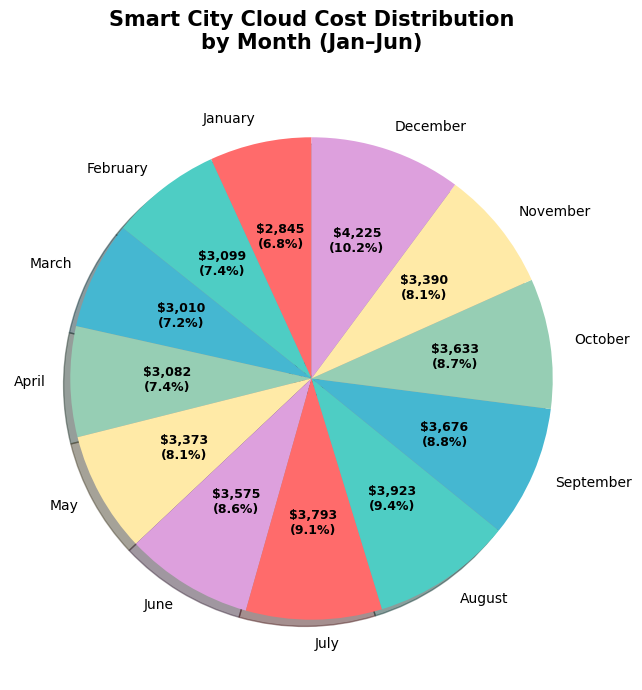

✅ Pie chart saved as 'pie_by_month.png'


In [7]:
month_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#F0A500', '#A8E6CF', '#FF8B94', '#C3A6FF', '#85C1E9', '#F8C471']

fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    monthly_cost.values,
    labels=monthly_cost.index,
    autopct=lambda p: f'${p * monthly_cost.sum() / 100:,.0f}\n({p:.1f}%)',
    colors=month_colors,
    startangle=90,
    shadow=True,
    textprops={'fontsize': 10}
)

for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

ax.set_title('Smart City Cloud Cost Distribution\nby Month (Jan–Dec)', 
             fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('pie_by_month.png', bbox_inches='tight', dpi=120)
plt.show()
print("✅ Pie chart saved as 'pie_by_month.png'")

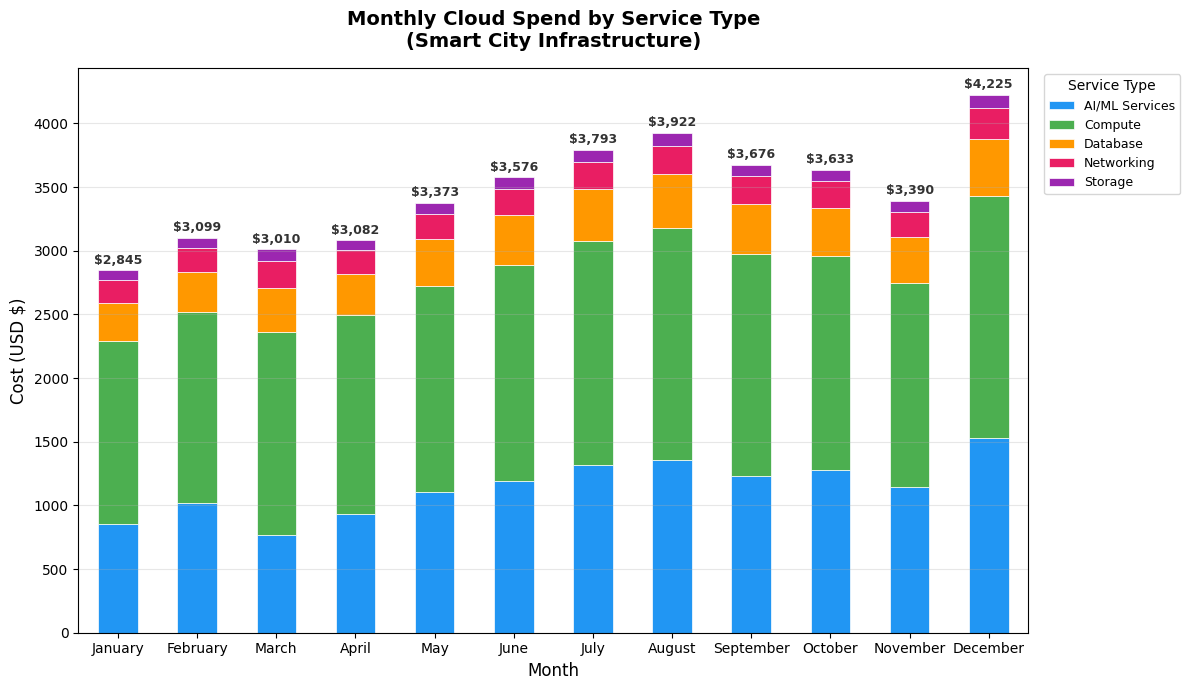

✅ Bar chart saved as 'bar_monthly_service.png'


In [8]:
pivot = df.pivot_table(values='Cost_USD', index='Month', columns='Service_Type', aggfunc='sum')
pivot = pivot.reindex(month_order)

ax = pivot.plot(kind='bar', stacked=True, figsize=(12, 7),
                color=['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0'],
                edgecolor='white', linewidth=0.5)

plt.title('Monthly Cloud Spend by Service Type\n(Smart City Infrastructure)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Cost (USD $)', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.legend(title='Service Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.grid(axis='y', alpha=0.3)

# Add total labels on top of each bar
for i, (month, row) in enumerate(pivot.iterrows()):
    total = row.sum()
    ax.text(i, total + 30, f'${total:,.0f}', ha='center', va='bottom', 
            fontsize=9, fontweight='bold', color='#333')

plt.tight_layout()
plt.savefig('bar_monthly_service.png', bbox_inches='tight', dpi=120)
plt.show()
print("✅ Bar chart saved as 'bar_monthly_service.png'")

## 📊 Step 9: Cost by Department

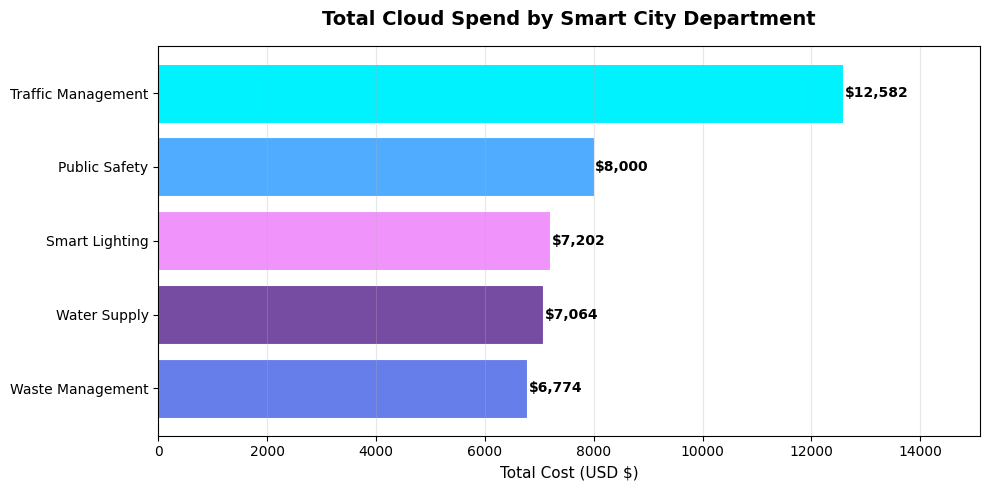

✅ Department chart saved!


In [9]:
dept_cost = df.groupby('Department')['Cost_USD'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(dept_cost.index, dept_cost.values, 
               color=['#667eea', '#764ba2', '#f093fb', '#4facfe', '#00f2fe'],
               edgecolor='white', linewidth=0.8)

# Add value labels
for bar, val in zip(bars, dept_cost.values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Total Cloud Spend by Smart City Department', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Cost (USD $)', fontsize=11)
ax.set_xlim(0, dept_cost.max() * 1.2)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('bar_by_department.png', bbox_inches='tight', dpi=120)
plt.show()
print("✅ Department chart saved!")

## 📤 Step 10: Export Summary Report to Excel

In [10]:
with pd.ExcelWriter('smart_city_cloud_report.xlsx', engine='openpyxl') as writer:
    
    # Sheet 1: Raw Data
    df.to_excel(writer, sheet_name='Raw Billing Data', index=False)
    
    # Sheet 2: Cost by Service Type
    service_df = service_cost.reset_index()
    service_df.columns = ['Service Type', 'Total Cost (USD)']
    service_df['% Share'] = (service_df['Total Cost (USD)'] / service_df['Total Cost (USD)'].sum() * 100).round(2)
    service_df.to_excel(writer, sheet_name='By Service Type', index=False)
    
    # Sheet 3: Cost by Month
    month_df = monthly_cost.reset_index()
    month_df.columns = ['Month', 'Total Cost (USD)']
    month_df.to_excel(writer, sheet_name='By Month', index=False)
    
    # Sheet 4: Cost by Department
    dept_df = dept_cost.reset_index()
    dept_df.columns = ['Department', 'Total Cost (USD)']
    dept_df.to_excel(writer, sheet_name='By Department', index=False)
    
    # Sheet 5: Pivot Table
    pivot.to_excel(writer, sheet_name='Monthly x Service Pivot')

print("✅ Excel report exported as 'smart_city_cloud_report.xlsx'")
print("📋 Sheets created:")
print("   1. Raw Billing Data")
print("   2. By Service Type")
print("   3. By Month")
print("   4. By Department")
print("   5. Monthly x Service Pivot")

✅ Excel report exported as 'smart_city_cloud_report.xlsx'
📋 Sheets created:
   1. Raw Billing Data
   2. By Service Type
   3. By Month
   4. By Department
   5. Monthly x Service Pivot


## 🧠 Step 11: Key Insights & Cost Intelligence Summary

In [11]:
total_spend = df['Cost_USD'].sum()
top_service = service_cost.idxmax()
top_service_cost = service_cost.max()
top_dept = df.groupby('Department')['Cost_USD'].sum().idxmax()
peak_month = monthly_cost.idxmax()
avg_monthly = monthly_cost.mean()

print("=" * 55)
print("🏙️  SMART CITY CLOUD COST INTELLIGENCE REPORT")
print("=" * 55)
print(f"\n💵 Total Cloud Spend (Jan–Dec): ${total_spend:,.2f}")
print(f"📅 Average Monthly Spend:       ${avg_monthly:,.2f}")
print(f"\n🔴 Highest Cost Service:        {top_service}")
print(f"   └─ Total Spend: ${top_service_cost:,.2f} "
      f"({top_service_cost/total_spend*100:.1f}% of budget)")
print(f"\n🏢 Highest Spending Department: {top_dept}")
print(f"\n📈 Peak Spending Month:         {peak_month}")
print(f"   └─ ${monthly_cost[peak_month]:,.2f}")

print("\n" + "=" * 55)
print("💡 RECOMMENDATIONS")
print("=" * 55)
print("1. AI/ML Services is the largest cost driver.")
print("   → Consider reserved instances or spot pricing.")
print("2. Compute costs are high and growing monthly.")
print("   → Implement auto-scaling policies.")
print("3. Storage costs are low — well optimized.")
print("   → Continue current tiered storage strategy.")
print("4. Review Traffic Management dept. cloud usage.")
print("   → Largest departmental spender.")

🏙️  SMART CITY CLOUD COST INTELLIGENCE REPORT

💵 Total Cloud Spend (Jan–Jun): $41,623.00
📅 Average Monthly Spend:       $3,468.58

🔴 Highest Cost Service:        Compute
   └─ Total Spend: $19,920.00 (47.9% of budget)

🏢 Highest Spending Department: Traffic Management

📈 Peak Spending Month:         December
   └─ $4,225.00

💡 RECOMMENDATIONS
1. AI/ML Services is the largest cost driver.
   → Consider reserved instances or spot pricing.
2. Compute costs are high and growing monthly.
   → Implement auto-scaling policies.
3. Storage costs are low — well optimized.
   → Continue current tiered storage strategy.
4. Review Traffic Management dept. cloud usage.
   → Largest departmental spender.


---
## ✅ Project Summary

| Task | Status |
|------|--------|
| Load CSV billing data with Pandas | ✅ Done |
| Group costs by Service Type | ✅ Done |
| Group costs by Month | ✅ Done |
| Pie chart – Service Type | ✅ Done |
| Pie chart – Month | ✅ Done |
| Stacked bar chart – Monthly x Service | ✅ Done |
| Department-wise analysis | ✅ Done |
| Export to Excel (5 sheets) | ✅ Done |
| Cost intelligence insights | ✅ Done |

**Technology Stack:** Python 3 · Pandas · Matplotlib · OpenPyXL · Jupyter Notebook

> *This project demonstrates cloud cost management and data analysis skills applied to Smart City IT infrastructure.*